# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Daniel Eta
**Student ID:** 43092028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [10]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

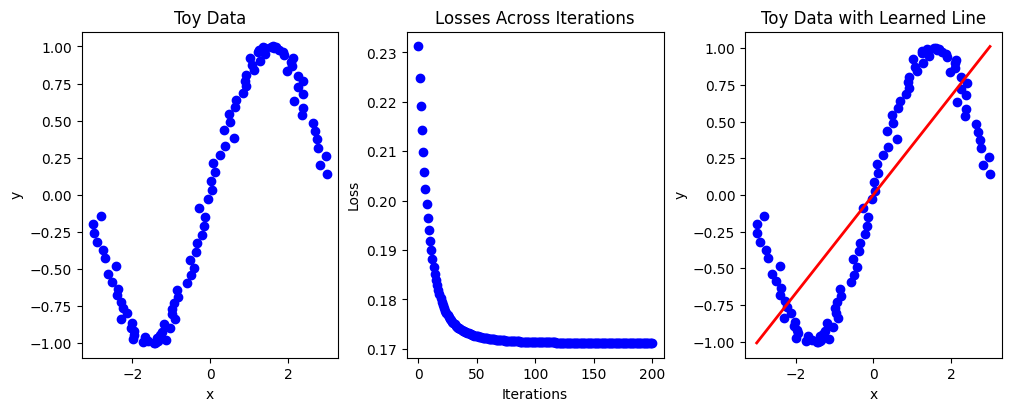

In [86]:
# I want three subplots, since it looks like this question will ask for three plots!
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), layout="constrained")

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) 
noise = np.random.normal(0, 0.1, size=x.shape)
x_noisy = x + noise # + small Gaussian noise (std=0.1)

# Plot it.
axs[0].scatter(x_noisy, y, color='blue')
axs[0].set_title('Toy Data')
axs[0].set_xlabel('x')      
axs[0].set_ylabel('y')     

# TODO: Initialise w and b to small random values.
w = 0.2
b = 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.01 # learning rate!
y_hat = w * x + b
loss  = np.mean((y_hat - y) ** 2)               # MSE
dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
db    = np.mean(2 * (y_hat - y))                # dLoss/db
w    -= lr * dw
b    -= lr * db
# print(loss, dw, db, w, b)

#   Record the loss at every step.
descent_data = [] # array of loss, derivatives, and updated weights and biases through the iterations.
iters = 0

while iters <= 200 and loss > 0.05: # keep looping until we hit 200 steps OR if the loss is low enough to stop training (0.05 loss)
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)               # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
    descent_data.append([loss, dw, db, w, b])
    iters += 1

# TODO: Plot (a) the loss curve over the 200 steps, and (b) the data with the fitted line on top.
losses = [innerarr[0] for innerarr in descent_data]
steps = [step for step in range(len(descent_data))]

# (a)
axs[1].scatter(steps, losses, color='blue')
axs[1].set_title('Losses Across Iterations')
axs[1].set_xlabel('Iterations')      
axs[1].set_ylabel('Loss')

# (b)
axs[2].scatter(x_noisy, y, color='blue')
axs[2].plot(x, y_hat, color='red', linewidth=2)
axs[2].set_title('Toy Data with Learned Line')
axs[2].set_xlabel('x')      
axs[2].set_ylabel('y')     
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
> 1. `dLoss/dw` derivative:
> $$L = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2$$
> Via the chain rule:
> $$\frac{\partial L}{\partial w} = \frac{1}{N} \sum_{i=1}^N 2(\hat{y}_i - y_i) \cdot \frac{\partial \hat{y}_i}{\partial w} = \frac{1}{N} \sum_{i=1}^N 2(\hat{y}_i - y_i) x_i$$
> This fits the code in the block above. $\frac{1}{N}$ is actually doing the same thing that `np.mean()` does.
> 2. This is a case of underfitting. Our model can't learn the requisite pattern in the first place, so it is fit *under* a requisite level. This happens because a single neuron > ($wx+b$) is simply incapable of learning a non-linear pattern, which a sinusoidal function is. Indeed, it is one of the major weaknesses of single-layer perceptrons (or neurons) in that whatever model they learn has to be linear. This can't be solved by simply training for much longer; modern techniques circumvent this by using more neurons (multi-layer perceptron).

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Text(0, 0.5, 'y')

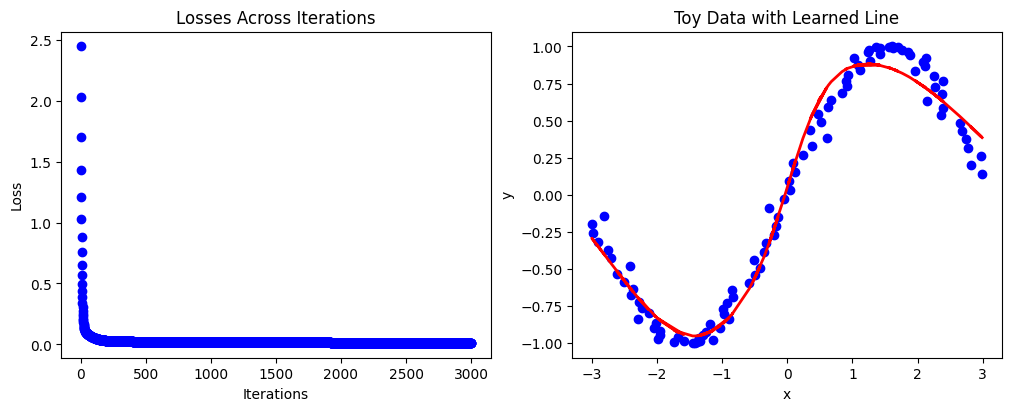

In [87]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8)
b1 = np.random.randn(8,)
W2 = np.random.randn(8, 1)
b2 = np.random.randn(1,)
# print(W1, "\n", b1, "\n", W2, "\n", b2)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
x = x_noisy.reshape(-1, 1) # Reshaped x values from the prior 1.2 section
y = y.reshape(-1, 1) # also reshape the 1D y array to 2D column vector (100, 1)

z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat 
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps, record the loss.
loss_data = []
iteration = []
for i in range(3000):
    # Forward Pass
    z1 = x @ W1 + b1
    h  = np.tanh(z1)
    # h = z1 # temporarily remove h1
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)

    loss_data.append(loss)
    iteration.append(i+1)

    # Backward Pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat 
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    # dz1 = dh # new dz1 if h=z1
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update Layer 1
    W1 -= lr * dW1
    b1 -= lr * db1

    # Update Layer 2
    W2 -= lr * dW2
    b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), layout="constrained")

# loss curve
axs[0].scatter(iteration, loss_data, color='blue')
axs[0].set_title('Losses Across Iterations')
axs[0].set_xlabel('Iterations')      
axs[0].set_ylabel('Loss')

# fit over data
axs[1].scatter(x, y, color='blue')
axs[1].plot(x, y_hat, color='red', linewidth=2)
axs[1].set_title('Toy Data with Learned Line')
axs[1].set_xlabel('x')      
axs[1].set_ylabel('y')  

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
> 1.  Without non-linearities (ReLU, sigmoid, tanh), any multi-layer network collapses into a single matrix transformation. In our context, without the tanh function, it simply becomes > a linear formula where $\hat{y}=W_2(W_1x+b_1)+b_2$. Regardless of how many hidden layers or neurons added, if there is no non-linear activator, the linear functions simply cascade  into a straight line via substitutions.
> 2. Every hidden neuron outputs a basis sinusoidal curve. Down the line, each curve was scaled and summed to create a final model fit. The hidden layer and the S-curve outputs were important in creating a non-linear model that actually fit the data. Relatedly, increasing the number of neurons also increases a model's capacity to learn finer, more intricate details of a curve.
> 3. The backpropagation technique, used to train neural networks, is an algorithm where the gradient of the loss with respect to each weight is derived and propagated backwards so that the weights may be updated with gradient descent.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

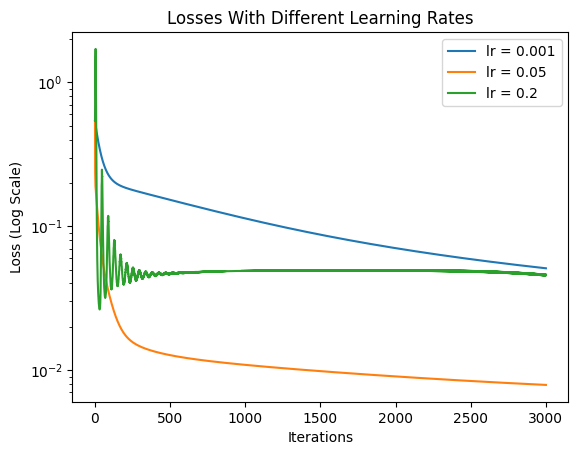

In [91]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000, seed=43):

    # Set seed so random numbers are identical on every call
    np.random.seed(seed) 
    
    # Initialise weights freshly inside the function
    W1 = np.random.randn(1, 8)
    b1 = np.zeros((8,))
    W2 = np.random.randn(8, 1)
    b2 = np.zeros((1,))
    
    loss_data = []
    
    for i in range(steps):
        # Forward Pass
        z1 = x @ W1 + b1
        h  = np.tanh(z1)
        # h = z1 # temporarily remove h1
        y_hat = h @ W2 + b2
        loss  = np.mean((y_hat - y) ** 2)

        # # Check for overflow/NaN during loss recording
        # if np.isnan(loss) or np.isinf(loss):
        #     loss = 1e6  # Cap at a arbitrary high finite scalar for plotting stability
    
        loss_data.append(loss)
    
        # Backward Pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat 
        db2 = d_yhat.sum(axis=0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
        # dz1 = dh # new dz1 if h=z1
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)
    
        # Update Layer 1
        W1 -= lr * dW1
        b1 -= lr * db1
    
        # Update Layer 2
        W2 -= lr * dW2
        b2 -= lr * db2

    return loss_data

loss_1 = train_toy(0.001)
loss_2 = train_toy(0.05)
loss_3 = train_toy(0.2)

iterations = range(1, len(loss_1) + 1)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.plot(iterations, loss_1, label='lr = 0.001')
plt.plot(iterations, loss_2, label='lr = 0.05')
plt.plot(iterations, loss_3, label='lr = 0.2')

# Enable logarithmic scale on y-axis to compare drastically different loss scales
plt.yscale('log') 

plt.xlabel('Iterations')
plt.ylabel('Loss (Log Scale)')
plt.title('Losses With Different Learning Rates')
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** The first blue learning rate curve (0.001) shows a steady decrease in the error across iterations. It descends steadily, and the error after the iterations are complete is not as low as its orange counterpart. With the orange line (lr=0.05), the loss drops sharply, plateauing at a much lower loss after the iterations. Interestingly, the green line (lr=0.2) shows very erratic behaviour. With it, we see that the loss decreases rapidly over a few iterations but for the remaining iterations, it oscillates back and forth—heavily reducing the loss and then increasing it back and forth. Quite clearly, we can see that its learning rate is too large. It can't descend into the bottom of the blow cleanly and instead takes overly large steps that causes it to miss the minimum and spend time going back and forth (oscillating).

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [71]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)
obesity_encoded = obesity.copy()
numeric_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; 
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity_encoded[col] = obesity_encoded[col].map({'yes': 1, 'no': 0})
    
# Gender/MTRANS/CAEC/CALC -> your justified choice).
frequency_order = ['no', 'Sometimes', 'Frequently', 'Always']
ord_encoder = OrdinalEncoder(categories=[frequency_order, frequency_order])
obesity_encoded[['CAEC', 'CALC']] = ord_encoder.fit_transform(obesity_encoded[['CAEC', 'CALC']])

obesity_encoded = pd.get_dummies(obesity_encoded, columns=['Gender', 'MTRANS'], drop_first=True, dtype=int)

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
target_encoder = LabelEncoder()
obesity_encoded['NObeyesdad'] = target_encoder.fit_transform(obesity_encoded['NObeyesdad'])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity_encoded.drop(columns=['NObeyesdad'])
y = obesity_encoded['NObeyesdad']

X_remainder, X_test, y_remainder, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=RANDOM_STATE
)

# Split to training/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_remainder, y_remainder, 
    test_size=0.25, 
    stratify=y_remainder, 
    random_state=RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_train.values, dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader

# 1. Combine feature and target tensors into a dataset object
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# test DataLoader
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=32, 
    shuffle=True  # Shuffle training data every epoch
)

# val
val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=32, 
    shuffle=False
)

# test
val_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=32, 
    shuffle=False
)

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [81]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
#         super().__init__()

#         h1, h2 = hidden_sizes
        
#         self.layer1 = nn.Linear(input_dim, h1) # first fully connected layer
#         self.relu1 = nn.ReLU()
#         self.layer2 = nn.Linear(h1, h2) # second fully connected layer
#         self.relu2 = nn.ReLU()
#         self.out = nn.Linear(h2, n_classes)
        
#     def forward(self, x):
#         x = self.relu1(self.layer1(x))
#         x = self.relu2(self.layer2(x))
#         x = self.out(x) # Returns raw logits (no activation on final layer)
#         return x

# The following is a rewrite of the FeedForwardNet module to take in a varying number of input dimensions for dynamic input layers
class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7,
        dropout=0.0,
    ):
        super().__init__()

        layers = []
        in_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# TODO: Instantiate, move to DEVICE, print the model.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeedForwardNet(input_dim = X_train.shape[1]).to(device)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
3591


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.8852 | Train Acc: 0.2836 | Val Loss: 1.7791 | Val Acc: 0.4344
Epoch 02/50 | Train Loss: 1.6153 | Train Acc: 0.4771 | Val Loss: 1.4220 | Val Acc: 0.4921
Epoch 03/50 | Train Loss: 1.2608 | Train Acc: 0.5561 | Val Loss: 1.0869 | Val Acc: 0.6485
Epoch 04/50 | Train Loss: 0.9691 | Train Acc: 0.6991 | Val Loss: 0.8505 | Val Acc: 0.7449
Epoch 05/50 | Train Loss: 0.7826 | Train Acc: 0.7622 | Val Loss: 0.7009 | Val Acc: 0.7765
Epoch 06/50 | Train Loss: 0.6497 | Train Acc: 0.8017 | Val Loss: 0.5868 | Val Acc: 0.8389
Epoch 07/50 | Train Loss: 0.5503 | Train Acc: 0.8428 | Val Loss: 0.4992 | Val Acc: 0.8784
Epoch 08/50 | Train Loss: 0.4727 | Train Acc: 0.8728 | Val Loss: 0.4303 | Val Acc: 0.9036
Epoch 09/50 | Train Loss: 0.4105 | Train Acc: 0.9013 | Val Loss: 0.3820 | Val Acc: 0.9084
Epoch 10/50 | Train Loss: 0.3653 | Train Acc: 0.9155 | Val Loss: 0.3311 | Val Acc: 0.9313
Epoch 11/50 | Train Loss: 0.3268 | Train Acc: 0.9107 | Val Loss: 0.2999 | Val Acc: 0.9360
Epoch 12/5

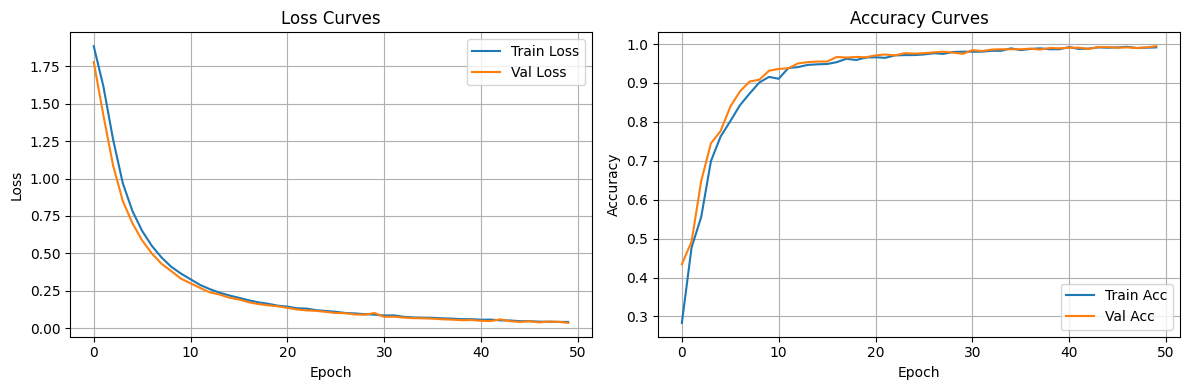

In [82]:
# TODO: 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

best_val_acc = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, 51): # 50 epochs
    model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader: # batches
        xb, yb = xb.to(device), yb.to(device)
    
        optimizer.zero_grad()  # Reset old gradients
        logits = model(xb)  # Forward pass
        loss = criterion(logits, yb)  # Calculate loss
        loss.backward()  # Backpropagate errors
        optimizer.step()  # Update weights
    
        # Track training stats step-by-step
        train_loss_sum += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
          xb, yb = xb.to(device), yb.to(device)
          logits = model(xb)
          loss = criterion(logits, yb)
        
          total_loss += loss.item() * xb.size(0)
          preds = torch.argmax(logits, dim=1)
          correct += (preds == yb).sum().item()
          total += yb.size(0)
        
    val_loss = total_loss / total
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
          f"Epoch {epoch:02d}/50 | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
      )

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(12, 4))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

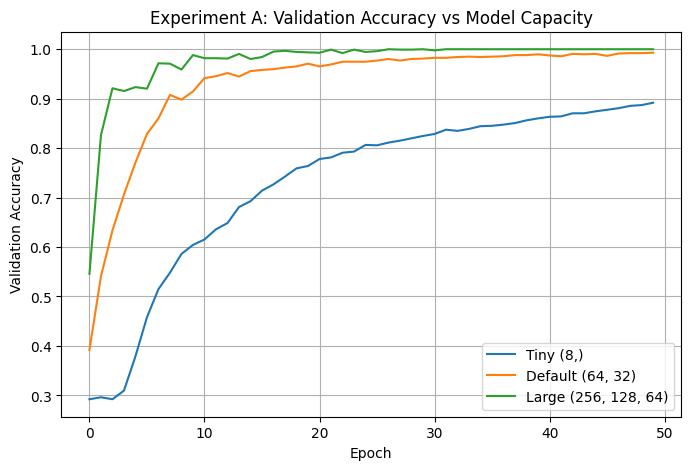

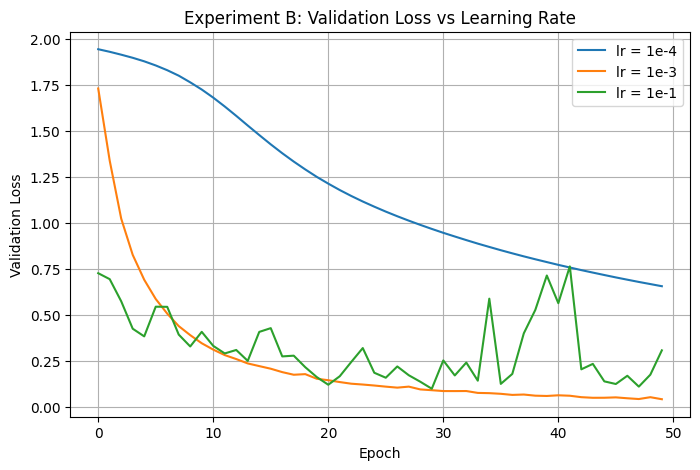

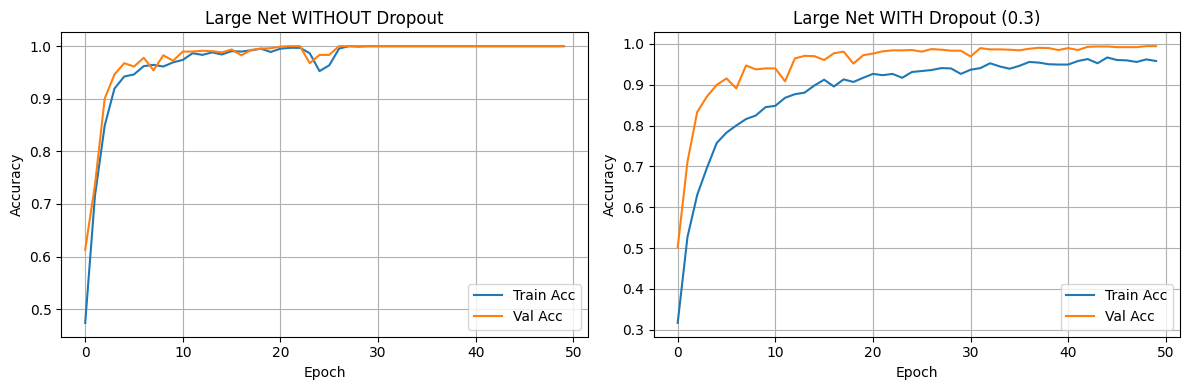

In [83]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0,
    verbose=False,
):
  # Re-create DataLoaders if batch_size changes
  train_loader_exp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  val_loader_exp = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

  model = FeedForwardNet(
      input_dim=X_train.shape[1],
      hidden_sizes=hidden_sizes,
      n_classes=7,
      dropout=dropout,
  ).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

  for epoch in range(1, epochs + 1):
    # Train 
    model.train()
    train_loss_sum, train_correct, train_total = 0.0, 0, 0
    for xb, yb in train_loader_exp:
      xb, yb = xb.to(device), yb.to(device)
      optimizer.zero_grad()
      logits = model(xb)
      loss = criterion(logits, yb)
      loss.backward()
      optimizer.step()

      train_loss_sum += loss.item() * xb.size(0)
      train_correct += (torch.argmax(logits, dim=1) == yb).sum().item()
      train_total += yb.size(0)

    # Validate 
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
      for xb, yb in val_loader_exp:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        val_loss_sum += loss.item() * xb.size(0)
        val_correct += (torch.argmax(logits, dim=1) == yb).sum().item()
        val_total += yb.size(0)

    t_loss =  train_loss_sum / train_total
    t_acc = train_correct / train_total
    v_loss = val_loss_sum / val_total
    v_acc = val_correct / val_total

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    if verbose and epoch % 10 == 0:
      print(f"Epoch {epoch:02d} | Val Acc: {v_acc:.4f}")

  return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
hist_tiny = run_experiment(hidden_sizes=(8,))
hist_default = run_experiment(hidden_sizes=(64, 32))
hist_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(8, 5))
plt.plot(hist_tiny["val_acc"], label="Tiny (8,)")
plt.plot(hist_default["val_acc"], label="Default (64, 32)")
plt.plot(hist_large["val_acc"], label="Large (256, 128, 64)")
plt.title("Experiment A: Validation Accuracy vs Model Capacity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
hist_lr_low = run_experiment(lr=1e-4)
hist_lr_med = run_experiment(lr=1e-3)
hist_lr_high = run_experiment(lr=1e-1)

plt.figure(figsize=(8, 5))
plt.plot(hist_lr_low["val_loss"], label="lr = 1e-4")
plt.plot(hist_lr_med["val_loss"], label="lr = 1e-3")
plt.plot(hist_lr_high["val_loss"], label="lr = 1e-1")
plt.title("Experiment B: Validation Loss vs Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
large_arch = (256, 128, 64)

hist_no_dropout = run_experiment(hidden_sizes=large_arch, dropout=0.0)
hist_with_dropout = run_experiment(hidden_sizes=large_arch, dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Without Dropout
axes[0].plot(hist_no_dropout["train_acc"], label="Train Acc")
axes[0].plot(hist_no_dropout["val_acc"], label="Val Acc")
axes[0].set_title("Large Net WITHOUT Dropout")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# With Dropout
axes[1].plot(hist_with_dropout["train_acc"], label="Train Acc")
axes[1].plot(hist_with_dropout["val_acc"], label="Val Acc")
axes[1].set_title("Large Net WITH Dropout (0.3)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.